# State-Level Public Investment and Economic Indicators Dataset

In [2]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel(
    "/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/Public Investment and Productivity Data.xlsx", 
    sheet_name="Prod Pubinvestment"
)
df.head(50)

#from OECD

,STATE,YR,P_CAP,HWY,WATER,UTIL,PC,GSP,EMP,UNEMP
0,ALABAMA,1970,15032.67,7325.80,1655.68,6051.20,35793.80,28418,1010.5,4.7
1,ALABAMA,1971,15501.94,7525.94,1721.02,6254.98,37299.91,29375,1021.9,5.2
2,ALABAMA,1972,15972.41,7765.42,1764.75,6442.23,38670.30,31303,1072.3,4.7
3,ALABAMA,1973,16406.26,7907.66,1742.41,6756.19,40084.01,33430,1135.5,3.9
4,ALABAMA,1974,16762.67,8025.52,1734.85,7002.29,42057.31,33749,1169.8,5.5
5,ALABAMA,1975,17316.26,8158.23,1752.27,7405.76,43971.71,33604,1155.4,7.7
6,ALABAMA,1976,17732.86,8228.19,1799.74,7704.93,50221.57,35764,1207.0,6.8
7,ALABAMA,1977,18111.93,8365.67,1845.11,7901.15,51084.99,37463,1269.2,7.4
8,ALABAMA,1978,18479.74,8510.64,1960.51,8008.59,52604.05,39964,1336.5,6.3
9,ALABAMA,1979,18881.49,8640.61,2081.91,8158.97,54525.86,40979,1362.0,7.1


STATE = state name<br>
ST_ABB = state abbreviation<br>
YR = 1970,...,1986<br>
P_CAP = public capital<br>
HWY = highway capital<br>
WATER = water utility capital<br>
UTIL = utility capital<br>
PC = private capital<br>
GSP = gross state product<br>
EMP = employment<br>
UNEMP = unemployment rate<br>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STATE   816 non-null    object 
 1   YR      816 non-null    int64  
 2   P_CAP   816 non-null    float64
 3   HWY     816 non-null    float64
 4   WATER   816 non-null    float64
 5   UTIL    816 non-null    float64
 6   PC      816 non-null    float64
 7   GSP     816 non-null    int64  
 8   EMP     816 non-null    float64
 9   UNEMP   816 non-null    object 
dtypes: float64(6), int64(2), object(2)
memory usage: 63.9+ KB


In [5]:
print(df.columns.tolist())
df.columns = df.columns.str.strip()
print(df.index.names)
df.reset_index(inplace=True)
print(df.isnull().sum())
data = df.dropna() 
print(df["STATE"].unique())
print(len(df["STATE"].unique()))

['STATE', 'YR', 'P_CAP', 'HWY', 'WATER', 'UTIL', 'PC', 'GSP', 'EMP', 'UNEMP']
[None]
index    0
STATE    0
YR       0
P_CAP    0
HWY      0
WATER    0
UTIL     0
PC       0
GSP      0
EMP      0
UNEMP    0
dtype: int64
['ALABAMA' 'ARIZONA' 'ARKANSAS' 'CALIFORNIA' 'COLORADO' 'CONNECTICUT'
 'DELAWARE' 'FLORIDA' 'GEORGIA' 'IDAHO' 'ILLINOIS' 'INDIANA' 'IOWA'
 'KANSAS' 'KENTUCKY' 'LOUISIANA' 'MAINE' 'MARYLAND' 'MASSACHUSETTS'
 'MICHIGAN' 'MINNESOTA' 'MISSISSIPPI' 'MISSOURI' 'MONTANA' 'NEBRASKA'
 'NEVADA' 'NEW_HAMPSHIRE' 'NEW_JERSEY' 'NEW_MEXICO' 'NEW_YORK'
 'NORTH_CAROLINA' 'NORTH_DAKOTA' 'OHIO' 'OKLAHOMA' 'OREGON' 'PENNSYLVANIA'
 'RHODE_ISLAND' 'SOUTH_CAROLINA' 'SOUTH_DAKOTA' 'TENNESSE' 'TEXAS' 'UTAH'
 'VERMONT' 'VIRGINIA' 'WASHINGTON' 'WEST_VIRGINIA' 'WISCONSIN' 'WYOMING']
48


# DATA STATISCAL DECRIPTION

In [6]:
description = df.describe()
print(description)

            index           YR          P_CAP           HWY         WATER  \
count  816.000000   816.000000     816.000000    816.000000    816.000000   
mean   407.500000  1978.000000   25036.657304  10218.423713   3618.784203   
std    235.703203     4.901984   27780.397399   9253.596822   4311.741579   
min      0.000000  1970.000000    2627.120000   1827.140000    228.460000   
25%    203.750000  1974.000000    7096.657500   3857.862500    764.510000   
50%    407.500000  1978.000000   17572.465000   7556.355000   2266.490000   
75%    611.250000  1982.000000   27691.567500  11266.547500   4318.697500   
max    815.000000  1986.000000  140217.320000  47699.420000  24592.330000   

               UTIL             PC            GSP           EMP  
count    816.000000     816.000000     816.000000    816.000000  
mean   11199.449424   58188.290588   61014.319853   1747.100858  
std    14768.866537   59770.780348   69973.904525   1855.987872  
min      538.490000    4052.710000    4354

# 1. THE POOLED OLS MODEL

$$
lnEMP_{it} = \beta_0 + \beta_1 lnPCAP_{it} + \beta_2 lnHWY_{it} + \beta_3 lnWATER_{it} + \beta_4 lnUNTIL_{it} + \epsilon_{it} 
$$

In [7]:
model = smf.ols(
    formula="np.log(EMP) ~ np.log(P_CAP) + np.log(HWY) + np.log(WATER) + np.log(UTIL)",
    data=df
)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            np.log(EMP)   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     6032.
Date:                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                        17:40:27   Log-Likelihood:                 225.49
No. Observations:                 816   AIC:                            -441.0
Df Residuals:                     811   BIC:                            -417.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.8579      0.233      3.687

# 2. FIXED EFFECTS MODELS

In [8]:
from linearmodels.panel import PanelOLS

df = df.set_index(['STATE', 'YR'])

y = df['EMP']
X = df[['P_CAP', 'HWY', 'WATER', 'UTIL']]

X = X.assign(constant=1)

model = PanelOLS(y, X, entity_effects=True)

fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    EMP   R-squared:                        0.5752
Estimator:                   PanelOLS   R-squared (Between):              0.9610
No. Observations:                 816   R-squared (Within):               0.5752
Date:                Sat, Dec 07 2024   R-squared (Overall):              0.9501
Time:                        17:40:28   Log-likelihood                   -5494.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      258.61
Entities:                          48   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(4,764)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):             258.61
                            

# RANDOM EFFECTS MODELS

In [9]:
from linearmodels.panel import PanelOLS
from linearmodels.panel import RandomEffects

y = df['EMP']
X = df[['P_CAP', 'HWY', 'WATER', 'UTIL']]

X = X.assign(constant=1)

model = PanelOLS(y, X, entity_effects=True)
model = RandomEffects(y, X)
re_results = model.fit()

print(re_results.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                    EMP   R-squared:                        0.7719
Estimator:              RandomEffects   R-squared (Between):              0.9723
No. Observations:                 816   R-squared (Within):               0.5733
Date:                Sat, Dec 07 2024   R-squared (Overall):              0.9610
Time:                        17:40:28   Log-likelihood                   -5521.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      685.94
Entities:                          48   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(4,811)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):             685.87
                            

# HAUSMAN TEST

In [10]:
from linearmodels.panel import PanelOLS, compare
from linearmodels.panel import compare

hausman_test = compare({'Fixed Effects': fe_results, 'Random Effects': re_results})

print(hausman_test)

                    Model Comparison                    
                         Fixed Effects    Random Effects
--------------------------------------------------------
Dep. Variable                      EMP               EMP
Estimator                     PanelOLS     RandomEffects
No. Observations                   816               816
Cov. Est.                   Unadjusted        Unadjusted
R-squared                       0.5752            0.7719
R-Squared (Within)              0.5752            0.5733
R-Squared (Between)             0.9610            0.9723
R-Squared (Overall)             0.9501            0.9610
F-statistic                     258.61            685.94
P-value (F-stat)                0.0000            0.0000
=====================     ============   ===============
P_CAP                           231.48            341.62
                              (0.1883)          (0.2774)
HWY                            -231.41           -341.54
                             (-

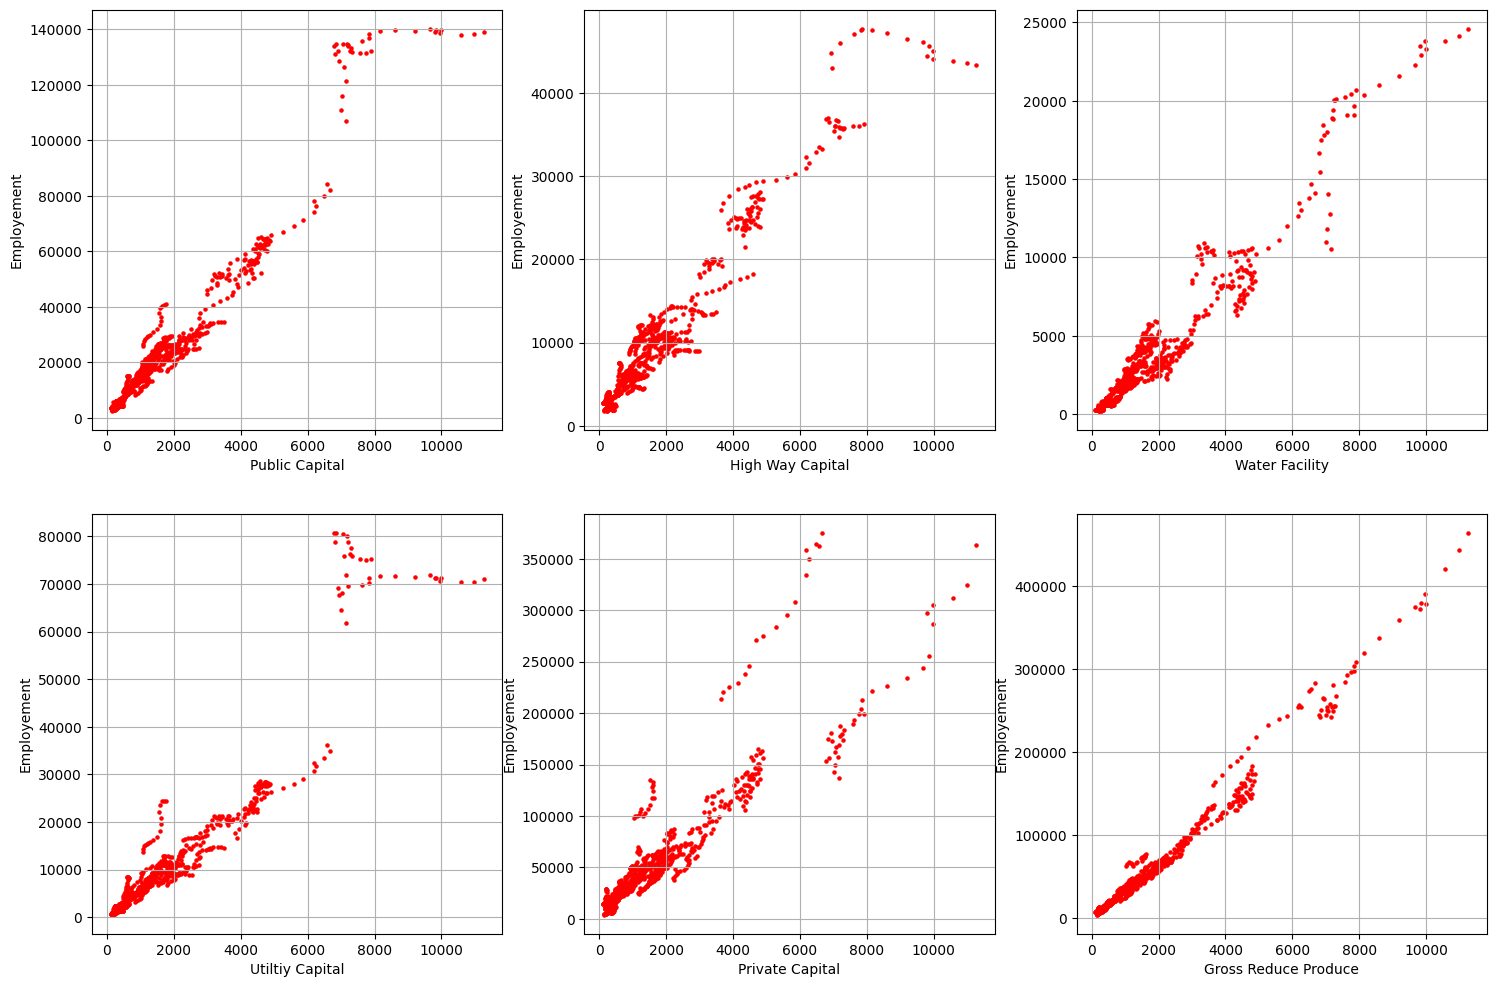

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

ax[0, 0].scatter(df["EMP"], df["P_CAP"], c="r", s=5)
ax[0, 0].grid()
ax[0, 0].set_xlabel("Public Capital")
ax[0, 0].set_ylabel("Employement")

ax[0, 1].scatter(df["EMP"], df["HWY"], c="r", s=5)
ax[0, 1].grid()
ax[0, 1].set_xlabel("High Way Capital")
ax[0, 1].set_ylabel("Employement")

ax[0, 2].scatter(df["EMP"], df["WATER"], c="r", s=5)
ax[0, 2].grid()
ax[0, 2].set_xlabel("Water Facility")
ax[0, 2].set_ylabel("Employement")

ax[1, 0].scatter(df["EMP"], df["UTIL"], c="r", s=5)
ax[1, 0].grid()
ax[1, 0].set_xlabel("Utiltiy Capital")
ax[1, 0].set_ylabel("Employement")

ax[1, 1].scatter(df["EMP"], df["PC"], c="r", s=5)
ax[1, 1].grid()
ax[1, 1].set_xlabel("Private Capital")
ax[1, 1].set_ylabel("Employement")

ax[1, 2].scatter(df["EMP"], df["GSP"], c="r", s=5)
ax[1, 2].grid()
ax[1, 2].set_xlabel("Gross Reduce Produce")
ax[1, 2].set_ylabel("Employement")

plt.show()

$$
lnEMP_{it} = \alpha_1 + \sum_{j=2}^{48} \alpha_j D_{ji} +\beta_2 lnPCAP_{it} + \beta_3 lnHWY_{it} + \beta_4 lnWATER_{it} + \beta_5 lnUTIL_{it} + u_{it}
$$

# TIME FIXED EFFECTS

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

df['lnEMP'] = np.log(df['EMP'])
df['lnPCAP'] = np.log(df['P_CAP'])
df['lnHWY'] = np.log(df['HWY'])
df['lnWATER'] = np.log(df['WATER'])
df['lnUTIL'] = np.log(df['UTIL'])

y = df['lnEMP']
X = df[['lnPCAP', 'lnHWY', 'lnWATER', 'lnUTIL'] + [col for col in df.columns if col.startswith('Year_')]]
X = sm.add_constant(X)  

# Estmiate Fixed Effects
model = sm.OLS(y, X).fit()
print(model.summary())

# Bước 5: Kiểm định tính dừng (ADF) cho từng biến
for col in ['lnEMP', 'lnPCAP', 'lnHWY', 'lnWATER', 'lnUTIL']:
    result = adfuller(df[col].dropna())
    print(f"ADF Test for {col}:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(f"Critical Values: {result[4]}")
    if result[1] <= 0.05:
        print(f"=> {col} is stationary.\n")
    else:
        print(f"=> {col} is not stationary.\n")


                            OLS Regression Results                            
Dep. Variable:                  lnEMP   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     6032.
Date:                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                        17:40:30   Log-Likelihood:                 225.49
No. Observations:                 816   AIC:                            -441.0
Df Residuals:                     811   BIC:                            -417.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8579      0.233      3.687      0.0

In [13]:
import statsmodels.api as sm

y, X = y.align(X, join='inner')

df['residuals'] = fe_results.resids
df['residuals_lag'] = df.groupby(level=0)['residuals'].shift(1)

df = df.dropna(subset=['residuals', 'residuals_lag'])

lag_model = sm.OLS(
    df['residuals'], 
    sm.add_constant(df['residuals_lag'])
).fit()

print(lag_model.summary())



df['residuals'] = fe_results.resids

df['residuals_lag'] = df.groupby(level=0)['residuals'].shift(1)

print(lag_model.summary())

rho = lag_model.params['residuals_lag']
n = len(df['residuals'].dropna())
F_statistic = (n - 2) * (rho ** 2) / (1 - rho ** 2)

from scipy.stats import f
p_value = 1 - f.cdf(F_statistic, 1, n - 2)
print(f"F-statistic: {F_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Have autocorrelation (reject H0).")
else:
    print("Haven't autocorrelation (fail to reject H0).")


                            OLS Regression Results                            
Dep. Variable:              residuals   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     4074.
Date:                Sat, 07 Dec 2024   Prob (F-statistic):          7.12e-309
Time:                        17:40:30   Log-Likelihood:                -4429.4
No. Observations:                 768   AIC:                             8863.
Df Residuals:                     766   BIC:                             8872.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.1129      2.796      2.186